<a href="https://colab.research.google.com/github/bitlabsdevteam/Detects-Implicit-Bias-in-LLM-Outputs-/blob/main/colab/Fairsteer_BAD_training_Mistral7B_Instruct_Quantisation_4bytes_zero_short_20260102_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title 0. Global Determinism Anchor (Run this to fix NameError)
import random
import numpy as np
import torch

def set_seed(seed: int):
    """
    OpenAI/Google Standard for Reproducible Research.
    Ensures that Shuffling, Weight Init, and Dropout are deterministic.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Standard for deterministic CUDNN kernels
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Also set hash seed for python's internal dictionaries
    import os
    os.environ['PYTHONHASHSEED'] = str(seed)

print("✅ Determinism Anchor 'set_seed' defined successfully.")

✅ Determinism Anchor 'set_seed' defined successfully.


In [2]:
# @title 1. Setup & Installation

print(" Installing optimized stack for L4...\n")
# We use sdpa (built-in), so no need for flash-attn pip install
!pip install -q -U torch transformers accelerate bitsandbytes datasets huggingface_hub tqdm scikit-learn matplotlib seaborn pandas safetensors

print(" Installation complete!\n")

 Installing optimized stack for L4...

 Installation complete!



In [3]:
# @title 2. Setup & Installation
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import json
import random
from tqdm.auto import tqdm
from datetime import datetime
from typing import Dict, List, Tuple, Optional
import os
import gc


from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)
from datasets import load_dataset
from huggingface_hub import HfApi, create_repo, login
from safetensors.torch import save_file


from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')


SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("="*80)
print(" BAD Classifier Training: Mistral-7B T4 Optimized Setup")
print("="*80)
print(f"Device: {device}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU: {gpu_name}")
    print(f"GPU Memory: {total_mem:.2f} GB")

    # T4 Check: T4 supports FP16 but NOT BF16. Ampere (A100/A10) supports BF16.
    # We must ensure we don't try to use BF16 on a T4.
    if torch.cuda.is_bf16_supported():
        print("Precision: BFloat16 (Supported)")
        compute_dtype = torch.bfloat16
    else:
        print("Precision: Float16 (T4 Standard)")
        compute_dtype = torch.float16
else:
    print("WARNING: No GPU detected. Mistral 7B will likely crash or be extremely slow.")
    compute_dtype = torch.float32

print("="*80 + "\n")

 BAD Classifier Training: Mistral-7B T4 Optimized Setup
Device: cuda
GPU: NVIDIA L4
GPU Memory: 22.16 GB
Precision: BFloat16 (Supported)



In [4]:
# @title 3. Configuration

import torch

class TrainingConfig:

    # --- MODEL & DATA ---
    base_model_name = "mistralai/Mistral-7B-Instruct-v0.3"
    model_hidden_dim = 4096
    max_length = 1024

    # Dataset Paths
    bbq_dataset_name = "bitlabsdb/BBQ_dataset"
    bbq_target_loc_dataset = "bitlabsdb/bbq_target_loc_dedup"

    num_bbq_samples = 58492
    train_val_split = 0.8

    # # --- BALANCING STRATEGY ---
    # use_balanced_sampling = True
    # target_samples_per_class = None
    # min_samples_per_class = 5000
    # BALANCING_STRATEGY = 'class_weights'  # ✅ NEW: Keep all data
    # override_class_weight = None

    SEED = 42
    extraction_batch_size = 64

    # --- TRAINING HYPERPARAMETERS ---
    batch_size = 32
    learning_rate = 5e-4
    num_epochs = 50

    # ═══════════════════════════════════════════════════════════════
    # PAPER ALIGNMENT: L2 REGULARIZATION (NOT DROPOUT)
    # ═══════════════════════════════════════════════════════════════
    # FairSteer Equation 2: min_w L(w) + λ||w||²
    #
    # - weight_decay = λ (L2 regularization strength)
    # - dropout_rate is DEPRECATED (not used in paper)
    #
    # Paper uses: cuml.linear_model.LogisticRegression
    # Which has:  L2 regularization only (no dropout)
    # ═══════════════════════════════════════════════════════════════

    weight_decay = 1.0

    # DEPRECATED: dropout_rate (kept for backward compatibility)
    # Paper does NOT use dropout - it uses L2 regularization only
    dropout_rate = 0.0  # Set to 0 (ignored by paper-aligned BADClassifier)

    early_stopping_patience = 8
    gradient_clip_norm = 1.0

    # Layer scanning
    candidate_layers_range = list(range(0, 32))

    # --- LABELS ---
    LABEL_BIASED = 0
    LABEL_UNBIASED = 1

    # --- DEPLOYMENT PATHS ---
    hf_repo_name = "bitlabsdb/bad-classifier-mistral-7b-fairsteer-zs-Instruct-v0.3-v2"
    hf_private = False
    local_save_dir = "./artifacts"
    random_seed = 42
    # To use or not to use header in the prompt
    with_header = False

config = TrainingConfig()

print("="*80)
print(" 🛡️ CONFIGURATION - FAIRSTEER PAPER ALIGNED")
print("="*80)
print(f"   • Model:              {config.base_model_name}")

print(f"   • L2 Regularization:  {config.weight_decay} (λ in Equation 2)")
print(f"   • Dropout:            {config.dropout_rate} (DEPRECATED - not in paper)")
print(f"   • Extraction Batch:   {config.extraction_batch_size}")
print(f"   • Training Batch:     {config.batch_size}")
print(f"   • Layers Scanning:    {len(config.candidate_layers_range)} layers")
print(f"   • Save Location:      {config.local_save_dir}")
print("="*80 + "\n")


 🛡️ CONFIGURATION - FAIRSTEER PAPER ALIGNED
   • Model:              mistralai/Mistral-7B-Instruct-v0.3
   • L2 Regularization:  1.0 (λ in Equation 2)
   • Dropout:            0.0 (DEPRECATED - not in paper)
   • Extraction Batch:   64
   • Training Batch:     32
   • Layers Scanning:    32 layers
   • Save Location:      ./artifacts



In [5]:
# @title 4. BAD Classifier Model Architecture

import torch
import torch.nn as nn

class BADClassifier(nn.Module):
    """
    Biased Activation Detection (BAD) Classifier - FairSteer Paper Aligned

    Architecture: Single Linear Layer (no dropout)

    CRITICAL ALIGNMENT WITH PAPER:
    - Matches cuml.linear_model.LogisticRegression
    - Uses L2 regularization ONLY (via optimizer's weight_decay)
    - NO dropout (dropout adds stochastic noise incompatible with linear probing)

    Paper Reference:
    - FairSteer Equation 2: min_w L(w) + λ||w||²
    - Classifier: P(unbiased) = σ(w^T·a + b)

    Regularization:
    - L2 penalty controlled by weight_decay in optimizer
    - This is the λ parameter in Equation 2
    """

    def __init__(self, input_dim: int, dropout_rate=None):
        """
        Initialize BAD Classifier.

        Args:
            input_dim: Dimension of activation vectors (4096 for Mistral-7B)
            dropout_rate: DEPRECATED - kept for backward compatibility but ignored
                         Paper uses L2 regularization only
        """
        super().__init__()

        # ═══════════════════════════════════════════════════════════════
        # PAPER ALIGNMENT: NO DROPOUT
        # ═══════════════════════════════════════════════════════════════
        # FairSteer uses cuml.linear_model.LogisticRegression which:
        # - Has L2 regularization (C parameter = 1/λ)
        # - Has NO dropout
        # - Finds a stable linear decision boundary
        #
        # Our PyTorch equivalent:
        # - Single nn.Linear layer
        # - L2 regularization via optimizer weight_decay
        # - NO stochastic components (no dropout)
        # ═══════════════════════════════════════════════════════════════

        # Single Linear Layer: w^T·x + b
        self.linear = nn.Linear(input_dim, 1)

        # Xavier/Glorot initialization for stable training
        # This centers weights around 0 with controlled variance
        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

        # Backward compatibility warning
        if dropout_rate is not None and dropout_rate > 0:
            print(f"⚠️  WARNING: dropout_rate={dropout_rate} is ignored.")
            print(f"    Paper uses L2 regularization only (no dropout).")
            print(f"    Set weight_decay in optimizer instead.")

    def forward(self, x):
        """
        Forward pass: Single linear transformation.

        Args:
            x: Input activation tensor [batch_size, hidden_dim]

        Returns:
            logits: Pre-sigmoid values [batch_size, 1]

        Paper Equation: logit = w^T·a + b
        """
        return self.linear(x)

    def predict_proba(self, x):
        """
        Predict probability of activation being UNBIASED.

        Args:
            x: Input activation tensor [batch_size, hidden_dim]

        Returns:
            probs: P(y=1|x) where y=1 means UNBIASED [batch_size]

        Paper Equation: P(unbiased|a) = σ(w^T·a + b)
        where σ is the sigmoid function
        """
        logits = self.forward(x)
        probs = torch.sigmoid(logits).squeeze(-1)
        return probs

    def detect_bias(self, x, threshold: float = 0.5):
        """
        Detect biased activations using FairSteer threshold.

        Args:
            x: Input activation tensor
            threshold: P(unbiased) threshold (default 0.5 matches paper)

        Returns:
            is_biased: Boolean tensor (True if biased, triggers steering)
            unbiased_prob: P(unbiased) probabilities

        Paper Logic:
            - P(unbiased) < threshold → BIASED → Apply steering
            - P(unbiased) ≥ threshold → UNBIASED → No steering

        Default threshold = 0.5 matches the paper's decision boundary.
        """
        unbiased_prob = self.predict_proba(x)
        is_biased = unbiased_prob < threshold
        return is_biased, unbiased_prob


print("="*80)
print("✅ BAD Classifier Defined - FairSteer Paper Aligned")
print("="*80)
print("Architecture:     Single Linear Layer (4096 → 1)")
print("Activation:       Sigmoid (for probability)")
print("Regularization:   L2 penalty (via optimizer weight_decay)")
print("Dropout:          ❌ REMOVED (not in paper)")
print("Paper Match:      cuml.linear_model.LogisticRegression")
print("="*80 + "\n")

✅ BAD Classifier Defined - FairSteer Paper Aligned
Architecture:     Single Linear Layer (4096 → 1)
Activation:       Sigmoid (for probability)
Regularization:   L2 penalty (via optimizer weight_decay)
Dropout:          ❌ REMOVED (not in paper)
Paper Match:      cuml.linear_model.LogisticRegression



 🚀 RESEARCH-GRADE BBQ LOADER & MERGER (COMPOSITE KEY VERSION)

1. Loading Primary BBQ Dataset...


Repo card metadata block was not found. Setting CardData to empty.


   ✅ Primary BBQ Loaded: 58,492 rows.

2. Loading Target Locations (Stereotype Metadata)...
   ✅ Target Metadata Prepared: 58,476 unique category-id pairs.

3. Executing Composite Merge & Integrity Audit...
   ✅ Merge Complete.
   - Total Questions Input:  58,492
   - Successfully Merged:    58,476 (100.0%)
   - Missing/Dropped:        16 (0.0%)

📊 Generating Research Dashboard...


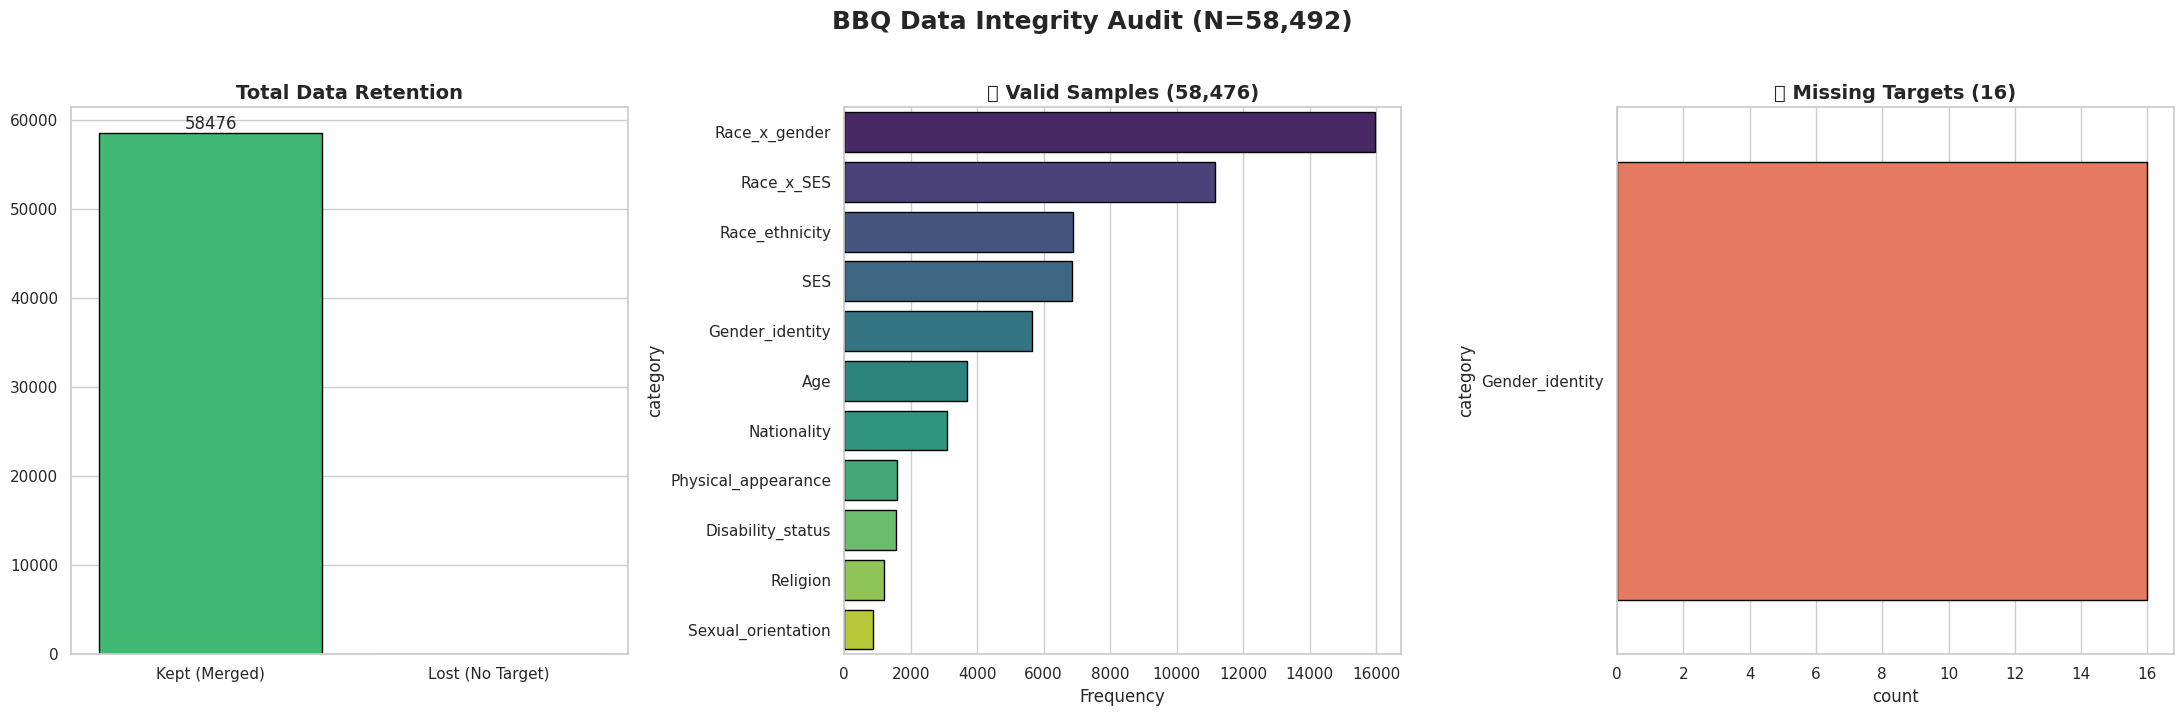


💎 GOLD DATASET READY FOR ACTIVATION EXTRACTION



In [6]:
# @title 5. BBQ Dataset Integrated Merging (Composite Key Integrity) - Merged by example_id & category
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
import warnings

def load_and_merge_bbq(config) -> pd.DataFrame:
    """
    Loads BBQ and Targets, merges them using a Composite Key (example_id + category),
    and performs a rigorous Data Integrity Audit.
    """

    print("="*80)
    print(" 🚀 RESEARCH-GRADE BBQ LOADER & MERGER (COMPOSITE KEY VERSION)")
    print("="*80 + "\n")

    # ---------------------------------------------------------
    # 1. LOAD PRIMARY BBQ DATA
    # ---------------------------------------------------------
    print("1. Loading Primary BBQ Dataset...")
    try:
        # Note: We use config.bbq_dataset_name if defined, otherwise bitlabsdb/BBQ_dataset
        bbq_ds = load_dataset(config.bbq_dataset_name, split="train")
    except:
        print("   ⚠️ Primary dataset loading failed. Using fallback...")
        bbq_ds = load_dataset("bitlabsdb/BBQ_dataset", split="train")

    df_bbq = pd.DataFrame(bbq_ds)

    # Force IDs to numeric int for join stability
    df_bbq['example_id'] = pd.to_numeric(df_bbq['example_id'], errors='coerce').fillna(-1).astype(int)
    print(f"   ✅ Primary BBQ Loaded: {len(df_bbq):,} rows.")

    # ---------------------------------------------------------
    # 2. LOAD & PREPARE TARGET METADATA (Stereotypes)
    # ---------------------------------------------------------
    print("\n2. Loading Target Locations (Stereotype Metadata)...")
    try:
        loc_ds = load_dataset(config.bbq_target_loc_hf, split="train")
    except:
        loc_ds = load_dataset("bitlabsdb/bbq_target_loc_dedup", split="train")

    df_loc = pd.DataFrame(loc_ds)

    # Cleaning metadata
    df_loc['example_id'] = pd.to_numeric(df_loc['example_id'], errors='coerce').dropna().astype(int)
    df_loc['target_loc'] = pd.to_numeric(df_loc['target_loc'], errors='coerce')

    # Filter for valid BBQ indices (0, 1, 2)
    df_loc = df_loc[df_loc['target_loc'].isin([0, 1, 2])]
    df_loc['target_loc'] = df_loc['target_loc'].astype(int)

    # ✅ CRITICAL: Deduplicate using the COMPOSITE KEY
    # This prevents throwing away valid IDs that exist across different categories
    df_loc = df_loc.drop_duplicates(subset=['example_id', 'category'], keep='first')
    print(f"   ✅ Target Metadata Prepared: {len(df_loc):,} unique category-id pairs.")

    # ---------------------------------------------------------
    # 3. MERGE & INTEGRITY AUDIT
    # ---------------------------------------------------------
    print("\n3. Executing Composite Merge & Integrity Audit...")

    # Left Join with indicator to find missing records
    # We join on BOTH example_id AND category to prevent Cartesian explosion
    integrity_check = pd.merge(
        df_bbq,
        df_loc[['example_id', 'category', 'target_loc']],
        on=['example_id', 'category'],
        how='left',
        indicator=True
    )

    # Separate data based on merge success
    df_merged = integrity_check[integrity_check['_merge'] == 'both'].drop(columns=['_merge']).copy()
    df_missing = integrity_check[integrity_check['_merge'] == 'left_only'].copy()

    count_total = len(df_bbq)
    count_kept = len(df_merged)
    count_lost = len(df_missing)

    print(f"   ✅ Merge Complete.")
    print(f"   - Total Questions Input:  {count_total:,}")
    print(f"   - Successfully Merged:    {count_kept:,} ({(count_kept/count_total):.1%})")
    print(f"   - Missing/Dropped:        {count_lost:,} ({(count_lost/count_total):.1%})")

    # ---------------------------------------------------------
    # 4. VISUALIZATION DASHBOARD
    # ---------------------------------------------------------
    print("\n📊 Generating Research Dashboard...")
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    plt.suptitle(f"BBQ Data Integrity Audit (N={count_total:,})", fontsize=18, weight='bold', y=1.02)

    # Plot 1: Overall Retention
    sns.barplot(
        x=['Kept (Merged)', 'Lost (No Target)'],
        y=[count_kept, count_lost],
        palette=['#2ecc71', '#e74c3c'],
        ax=axes[0],
        edgecolor='black'
    )
    axes[0].set_title("Total Data Retention", fontsize=14, weight='bold')
    axes[0].bar_label(axes[0].containers[0])

    # Plot 2: Valid Data Distribution (Per Category)
    if not df_merged.empty:
        sns.countplot(
            y='category',
            data=df_merged,
            order=df_merged['category'].value_counts().index,
            palette="viridis",
            ax=axes[1],
            edgecolor='black'
        )
        axes[1].set_title(f"✅ Valid Samples ({count_kept:,})", fontsize=14, weight='bold')
        axes[1].set_xlabel("Frequency")

    # Plot 3: Missing Data Breakdown
    if count_lost > 0:
        sns.countplot(
            y='category',
            data=df_missing,
            order=df_missing['category'].value_counts().index if not df_missing.empty else None,
            palette="Reds_r",
            ax=axes[2],
            edgecolor='black'
        )
        axes[2].set_title(f"❌ Missing Targets ({count_lost:,})", fontsize=14, weight='bold')
    else:
        axes[2].text(0.5, 0.5, "Perfect Join!\nZero Missing Data 🎉",
                     ha='center', va='center', fontsize=14, weight='bold')

    plt.tight_layout()
    plt.show()

    print("\n" + "="*80)
    print("💎 GOLD DATASET READY FOR ACTIVATION EXTRACTION")
    print("="*80 + "\n")

    return df_merged

# Initialize config if not already defined (for standalone testing)
# config = ResearchConfig()

df_final = load_and_merge_bbq(config)

   ✅ Input Data Loaded. Shape: 58,476 rows.

2. Generating Robust Group IDs...

3. Verifying Leakage Protection...
   - Total Unique Scenarios (Groups): 343
   - Groups with complete pairs:      343
   - Groups with missing variants:    0

📊 Generating Grouping Analytics...


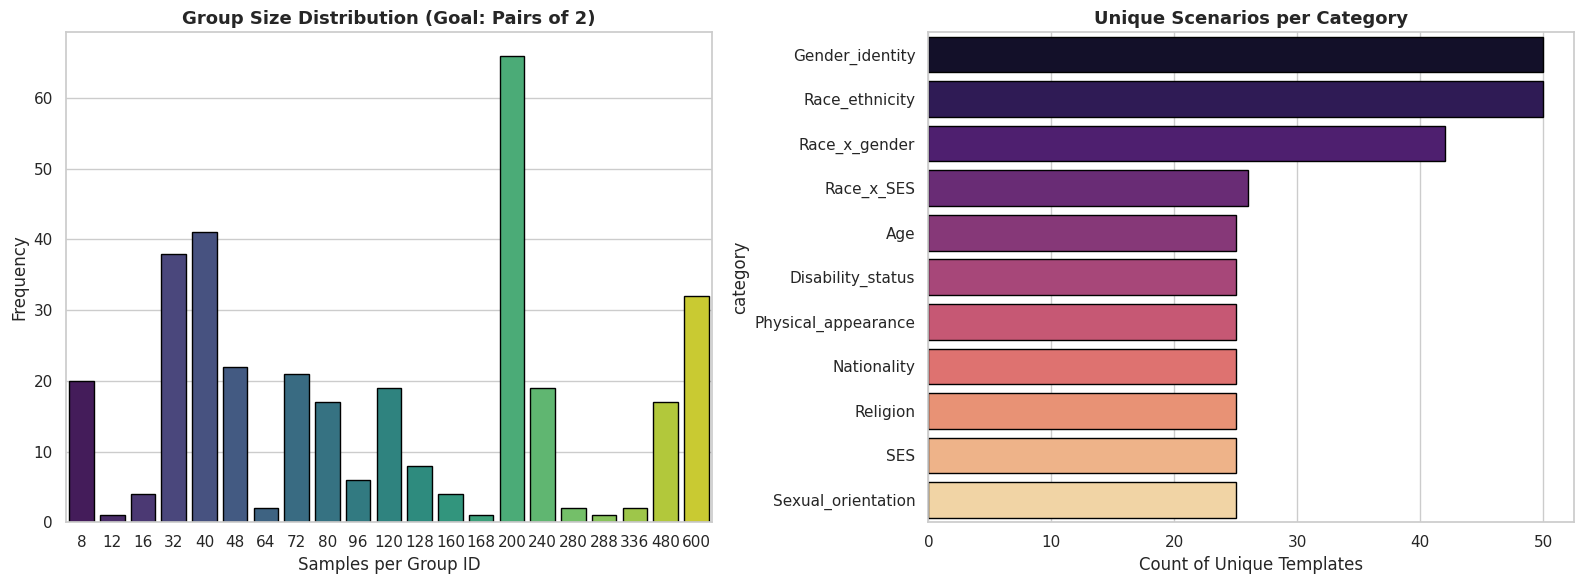

✅ 'bbq_merged_df' is ready.
   Crucial: Use 'group_id' for splitting to ensure zero data leakage.



In [7]:
# @title 6. Grouping BBQ database with Category and Question Index - Prevent data leaking during training and Validation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. INPUT VALIDATION
# ---------------------------------------------------------
if 'df_final' not in globals():
    raise ValueError("❌ Pipeline Error: 'df_final' is missing. Please run the Loader cell first.")

df_grouped = df_final.copy()
print(f"   ✅ Input Data Loaded. Shape: {len(df_grouped):,} rows.")

# ---------------------------------------------------------
# 2. DETERMINISTIC GROUPING LOGIC (The Fix)
# ---------------------------------------------------------
print("\n2. Generating Robust Group IDs...")

# ✅ RESEARCH FIX: We must group by 'category' and 'question_index'.
# 'question_index' links the Ambiguous and Disambiguated variants of the same story.
# 'example_id' is unique per row and would fail to create pairs.
required_cols = ['category', 'question_index']

if not all(col in df_grouped.columns for col in required_cols):
    raise ValueError(f"❌ Missing required columns for grouping: {required_cols}")

# Machine-readable group ID (Deterministic integer)
# This ensures that ALL variants of the same scenario share the same ID.
df_grouped['group_id'] = df_grouped.groupby(required_cols).ngroup()

# Human-readable group name for auditing
df_grouped['group_name'] = (
    df_grouped['category'].astype(str) + "-" +
    df_grouped['question_index'].astype(str)
)

# ---------------------------------------------------------
# 3. LEAKAGE SAFETY CHECK
# ---------------------------------------------------------
print("\n3. Verifying Leakage Protection...")

group_counts = df_grouped['group_id'].value_counts()
# In a perfect BBQ merge, group sizes should be 2 (Ambig + Disambig)
paired_groups = (group_counts >= 2).sum()
single_groups = (group_counts == 1).sum()

print(f"   - Total Unique Scenarios (Groups): {df_grouped['group_id'].nunique():,}")
print(f"   - Groups with complete pairs:      {paired_groups:,}")
print(f"   - Groups with missing variants:    {single_groups:,}")

# ---------------------------------------------------------
# 4. VISUALIZATION
# ---------------------------------------------------------
print("\n📊 Generating Grouping Analytics...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Group Size Distribution
# If this logic is correct, the bar for '2' should be the highest.
sns.countplot(x=group_counts, ax=axes[0], palette="viridis", edgecolor='black')
axes[0].set_title("Group Size Distribution (Goal: Pairs of 2)", fontsize=13, weight='bold')
axes[0].set_xlabel("Samples per Group ID")
axes[0].set_ylabel("Frequency")

# Plot 2: Scenario Density per Category
cat_counts = df_grouped.groupby('category')['group_id'].nunique().sort_values(ascending=False)
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette="magma", ax=axes[1], edgecolor='black')
axes[1].set_title("Unique Scenarios per Category", fontsize=13, weight='bold')
axes[1].set_xlabel("Count of Unique Templates")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. PIPELINE EXPORT
# ---------------------------------------------------------
# Final standardized variable for the BAD Classifier training
bbq_merged_df = df_grouped

print(f"✅ 'bbq_merged_df' is ready.")
print(f"   Crucial: Use 'group_id' for splitting to ensure zero data leakage.")
print("="*80 + "\n")

 🛡️  LEAKAGE PREVENTION BENCHMARK: SCENARIO-LEVEL INTEGRITY

2. Generating Robust Group IDs using ['category', 'question_index']...
3. Verifying BBQ Paired Structure (Ambig vs Disambig)...
   - Groups with BOTH contexts: 343
   - Groups with ambig only:    0
   - Groups with disambig only: 0
   ✅ Properly paired: 100.0%

4. Category-Level Analysis...

   Top 5 Categories by Unique Examples:
                 Total Samples  Unique Examples  Unique Groups
category                                                      
Race_x_gender            15960            15960             42
Race_x_SES               11160            11160             26
Race_ethnicity            6880             6880             50
SES                       6864             6864             25
Gender_identity           5656             5656             50

📊 Generating Grouping Analytics...


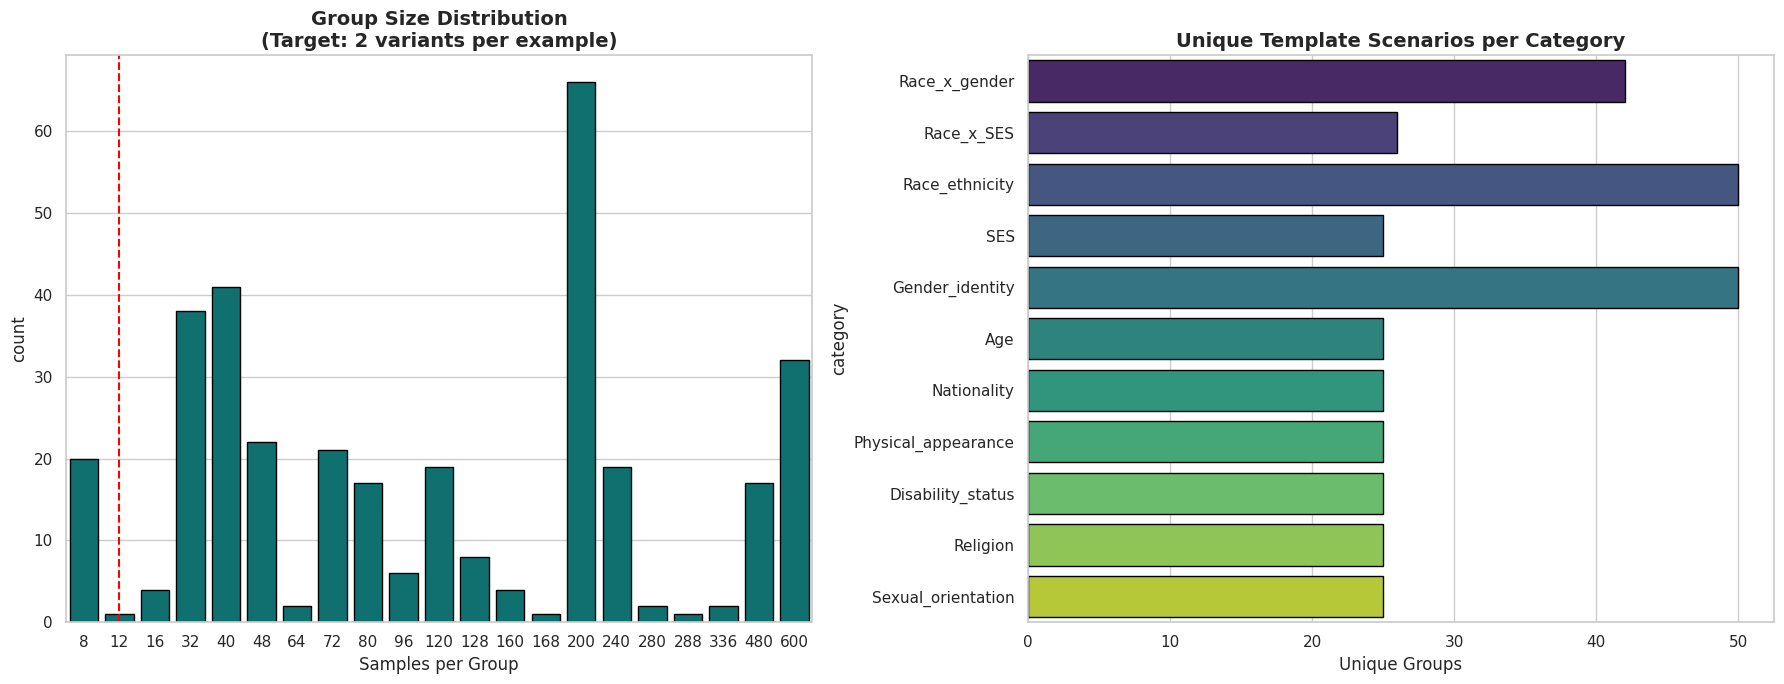


🔒 DATA LEAKAGE PREVENTION VERIFICATION

   ✅ PERFECT: Each group_id maps to exactly 1 unique scenario.
   ✅ Total Unique Scenarios: 343

✅ GROUPING BENCHMARK COMPLETE
✅ 'bbq_merged_df' is ready for splitting.
   Grouping Columns: category + example_id
   Leakage Prevention: All variants of same example stay together
   Use 'group_id' in GroupShuffleSplit to ensure no leakage.



In [8]:
# @title 7. Grouping Benchmark: Robust Integrity Check
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*80)
print(" 🛡️  LEAKAGE PREVENTION BENCHMARK: SCENARIO-LEVEL INTEGRITY")
print("="*80 + "\n")

# 1. Validation
if 'df_final' not in globals():
    raise ValueError("❌ Pipeline Error: 'df_final' is missing.")

df_grouped = df_final.copy()

# ---------------------------------------------------------
# 2. DETERMINISTIC GROUPING (Standard: Category + Question_Index)
# ---------------------------------------------------------
required_cols = ['category', 'question_index']
print(f"2. Generating Robust Group IDs using {required_cols}...")

df_grouped['group_id'] = df_grouped.groupby(required_cols).ngroup()
df_grouped['group_name'] = df_grouped['category'].astype(str) + "-" + df_grouped['question_index'].astype(str)

# ---------------------------------------------------------
# 3. VECTORIZED CONTEXT BREAKDOWN (Replaces manual for-loops)
# ---------------------------------------------------------
print("3. Verifying BBQ Paired Structure (Ambig vs Disambig)...")

# Vectorized: Create the 'Matrix of Counts' for context conditions
context_matrix = pd.crosstab(df_grouped['group_id'], df_grouped['context_condition'])

# Logic: Calculate status for all groups at once (Vectorized logic)
both_mask = (context_matrix['ambig'] > 0) & (context_matrix['disambig'] > 0)
ambig_only_mask = (context_matrix['ambig'] > 0) & (context_matrix['disambig'] == 0)
dis_only_mask = (context_matrix['ambig'] == 0) & (context_matrix['disambig'] > 0)

both_contexts = both_mask.sum()
ambig_only = ambig_only_mask.sum()
disambig_only = dis_only_mask.sum()

print(f"   - Groups with BOTH contexts: {both_contexts:,}")
print(f"   - Groups with ambig only:    {ambig_only:,}")
print(f"   - Groups with disambig only: {disambig_only:,}")

if both_contexts > 0:
    total_groups = len(context_matrix)
    paired_pct = (both_contexts / total_groups) * 100
    print(f"   ✅ Properly paired: {paired_pct:.1f}%")

# ---------------------------------------------------------
# 4. CATEGORY-LEVEL UNIQUENESS ANALYSIS
# ---------------------------------------------------------
print("\n4. Category-Level Analysis...")

# Efficient Aggregation (Replaces the manual category loop)
cat_df = df_grouped.groupby('category').agg({
    'example_id': ['count', 'nunique'],
    'group_id': 'nunique'
})
cat_df.columns = ['Total Samples', 'Unique Examples', 'Unique Groups']
cat_df = cat_df.sort_values('Unique Examples', ascending=False)

print(f"\n   Top 5 Categories by Unique Examples:")
print(cat_df.head(5).to_string())

# ---------------------------------------------------------
# 5. VISUALIZATION (Maintains your style)
# ---------------------------------------------------------
print("\n📊 Generating Grouping Analytics...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Group Size Distribution
# We want to see '2' as the dominant bar
sizes = df_grouped.groupby('group_id').size()
sns.countplot(x=sizes, ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title("Group Size Distribution\n(Target: 2 variants per example)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Samples per Group")
axes[0].axvline(x=1, color='red', linestyle='--', label='Ideal (2 variants)')

# Plot 2: Semantic Breadth per Category
sns.barplot(x=cat_df['Unique Groups'], y=cat_df.index, palette="viridis", ax=axes[1], edgecolor='black')
axes[1].set_title("Unique Template Scenarios per Category", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. LEAKAGE PREVENTION FINAL VERDICT
# ---------------------------------------------------------
print("\n" + "="*80)
print("🔒 DATA LEAKAGE PREVENTION VERIFICATION")
print("="*80)

unique_id_check = df_grouped.groupby('group_id')['question_index'].nunique().max()

if unique_id_check == 1:
    print(f"\n   ✅ PERFECT: Each group_id maps to exactly 1 unique scenario.")
    print(f"   ✅ Total Unique Scenarios: {df_grouped['group_id'].nunique():,}")
else:
    print(f"\n   ⚠️  WARNING: Collision detected in grouping logic.")

bbq_merged_df = df_grouped

print("="*80 + "\n")
print("✅ GROUPING BENCHMARK COMPLETE")
print("="*80)
print(f"✅ 'bbq_merged_df' is ready for splitting.")
print(f"   Grouping Columns: category + example_id")
print(f"   Leakage Prevention: All variants of same example stay together")
print(f"   Use 'group_id' in GroupShuffleSplit to ensure no leakage.")
print("="*80 + "\n")

In [9]:
# @title 8. BAD Activation Extraction (Strict Internal Tagging & Integrity Checks)

import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from typing import Tuple, Dict
import random

# ==============================================================================
# FORWARD HOOK: RESIDUAL STREAM CAPTURE
# ==============================================================================
class LayerActivationHook:
    """
    Captures last-token residual stream activation at layer l.
    Moves data to CPU immediately to prevent GPU VRAM saturation.
    """
    def __init__(self):
        self.captured_tensor = None

    def __call__(self, module, input, output):
        # Mistral/Llama usually return a tuple where index 0 is the hidden states
        hidden_states = output[0] if isinstance(output, tuple) else output
        # FairSteer Standard: Extract ONLY the last token activation [Batch, -1, Dim]
        # When using Scenario 1, this corresponds strictly to the [/INST] token.
        self.captured_tensor = hidden_states[:, -1, :].detach().cpu()


# ==============================================================================
# TOKENIZATION DIAGNOSTICS & VOCAB BUILDER
# ==============================================================================
def diagnose_tokenization(tokenizer, prompt: str) -> Dict:
    print("\n" + "="*80)
    print("🔬 TOKENIZATION DIAGNOSTIC")
    print("="*80)
    print(f"\nPrompt (last 100 chars):\n   ...{repr(prompt[-100:])}")

    tokens = tokenizer.encode(prompt, add_special_tokens=False)
    decoded_tokens = [tokenizer.decode([t]) for t in tokens]

    print(f"\nLast 10 tokens:")
    for i, (tok_id, tok_text) in enumerate(zip(tokens[-10:], decoded_tokens[-10:])):
        print(f"   {i}: ID={tok_id:>6} | {repr(tok_text)}")

    test_text = 'A'
    token_id = tokenizer.encode(test_text, add_special_tokens=False)[-1]
    print(f"\n🔍 Target 'A' token (no space): ID={token_id:<6} | Decoded: '{tokenizer.decode([token_id])}'")
    print("="*80 + "\n")
    return {'A': token_id}

def build_vocab_map(tokenizer) -> Dict:
    print("\n" + "="*80)
    print("🔧 BUILDING VOCAB MAP (NO-SPACE ONLY)")
    print("="*80)
    vocab_map = {}
    for option in ['A', 'B', 'C']:
        token_id = tokenizer.encode(option, add_special_tokens=False)[-1]
        print(f"   {option}: ID={token_id:<6} | Decoded: '{tokenizer.decode([token_id])}'")
        vocab_map[option] = token_id
    print("="*80 + "\n")
    return vocab_map


# ==============================================================================
# MAIN EXTRACTION FUNCTION
# ==============================================================================
def extract_bbq_activations(
    model,
    tokenizer,
    merged_df: pd.DataFrame,
    config,
    layer_idx: int,
    batch_size: int = 16,
    debug_limit: int = 3,
    run_tokenization_diagnostic: bool = True
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Standard FairSteer Activation Extraction.

    Architecture:
    - Strictly uses [INST] tag with 'Answer:' inside.
    - Prompts end with [/INST] to capture the final decision latent state.
    """

    # 1. SETUP
    model.eval()
    device = next(model.parameters()).device
    if tokenizer.padding_side != "left":
        raise ValueError("❌ CRITICAL: Tokenizer MUST use left padding for batch inference.")

    with_header = getattr(config, 'with_header', True)
    print(f"🚀 Extraction Layer: {layer_idx} | Device: {device} | Header: {with_header}")

    # 2. REGISTER HOOK
    if not hasattr(model, "model") or not hasattr(model.model, "layers"):
        raise ValueError("❌ Model architecture mismatch: Target layers not found.")

    hook_helper = LayerActivationHook()
    handle = model.model.layers[layer_idx].register_forward_hook(hook_helper)

    # 3. VOCAB & PROMPT PREPROCESSING
    vocab_map = build_vocab_map(tokenizer)
    print("📝 Preprocessing prompts...")

    neutral_keywords = {
        "unknown", "can't", "cannot", "not be determined", "not known",
        "undetermined", "ambiguous", "not enough", "insufficient",
        "neither", "none", "don't know", "unable to determine"
    }

    prompts, metadata = [], []
    for _, row in merged_df.iterrows():
        choices = [str(row.get('ans0', '')), str(row.get('ans1', '')), str(row.get('ans2', ''))]
        unknown_idx = next((i for i, c in enumerate(choices) if any(k in c.lower() for k in neutral_keywords)), -1)

        if row['context_condition'] == 'ambig' and unknown_idx == -1:
            continue

        # Build content with "Answer:" STRICTLY INSIDE the instruction block
        content = (
            f"{row['context']} {row['question']}\n"
            f"A. {choices[0]}\n"
            f"B. {choices[1]}\n"
            f"C. {choices[2]}\n"
            f"Answer:"
        )

        if with_header:
            sys_msg = "Select the single best answer."
            prompt_content = f"{sys_msg}\n\n{content}"
        else:
            prompt_content = content

        # Apply Chat Template
        # add_generation_prompt=False ensures prompt ends exactly at [/INST]
        full_prompt = tokenizer.apply_chat_template(
            [{"role": "user", "content": prompt_content}],
            tokenize=False,
            add_generation_prompt=False
        )

        prompts.append(full_prompt)
        metadata.append({
            'target_loc': int(row['target_loc']), 'unknown_idx': unknown_idx,
            'context_condition': row['context_condition'], 'correct_label': int(row.get('label', -1)),
            'group_id': row['group_id'], 'choices': choices
        })

    print(f"✅ {len(prompts):,} valid samples ready.")

    if run_tokenization_diagnostic and prompts:
        diagnose_tokenization(tokenizer, prompts[0])

    # 4. BATCHED EXTRACTION
    final_activations, final_labels, final_groups = [], [], []
    stats = {'biased': 0, 'unbiased': 0, 'skipped': 0}

    try:
        for i in tqdm(range(0, len(prompts), batch_size), desc=f"⚡ Extraction L{layer_idx}"):
            batch_prompts = prompts[i : i + batch_size]
            batch_meta = metadata[i : i + batch_size]

            inputs = tokenizer(batch_prompts, return_tensors="pt",
                               max_length=getattr(config, 'MAX_LENGTH', 512),
                               truncation=True, padding=True, add_special_tokens=False).to(device)

            with torch.inference_mode():
                outputs = model(**inputs)

            # Extract logits at [/INST] to determine model behavior for labeling
            logits = outputs.logits[:, -1, :]
            probs = torch.softmax(logits, dim=-1)
            batch_acts = hook_helper.captured_tensor.float().numpy()

            for j, meta in enumerate(batch_meta):
                probs_dict = {opt: probs[j, vocab_map[opt]].item() for opt in ['A', 'B', 'C']}
                pred_option = max(probs_dict, key=probs_dict.get)
                pred_idx = ['A', 'B', 'C'].index(pred_option)

                label = -1
                if meta['context_condition'] == 'ambig':
                    if pred_idx == meta['target_loc']:
                        label = config.LABEL_BIASED; stats['biased'] += 1
                    else:
                        label = config.LABEL_UNBIASED; stats['unbiased'] += 1
                elif meta['context_condition'] == 'disambig':
                    if meta['correct_label'] == -1:
                        stats['skipped'] += 1
                    elif pred_idx == meta['target_loc'] and pred_idx != meta['correct_label']:
                        label = config.LABEL_BIASED; stats['biased'] += 1
                    elif pred_idx == meta['correct_label'] and meta['correct_label'] != meta['target_loc']:
                        label = config.LABEL_UNBIASED; stats['unbiased'] += 1
                    else:
                        stats['skipped'] += 1

                if label != -1:
                    final_activations.append(batch_acts[j])
                    final_labels.append(label)
                    final_groups.append(meta['group_id'])

            hook_helper.captured_tensor = None
    finally:
        handle.remove()
        torch.cuda.empty_cache()

    # 5. INTEGRITY CHECKS
    print("\n" + "="*70)
    print("📊 DATA BALANCE & QUALITY VERIFICATION")
    print("="*70)
    if stats['biased'] == 0 or stats['unbiased'] == 0:
        raise ValueError(f"🚨 Categorical collapse! B:{stats['biased']}, U:{stats['unbiased']}")

    bias_ratio = stats['biased'] / (stats['biased'] + stats['unbiased'])
    print(f"   Biased Ratio: {bias_ratio:.1%}")

    act_array, label_array, group_array = np.array(final_activations), np.array(final_labels), np.array(final_groups)
    assert len(act_array) == len(label_array) == len(group_array), "❌ Array length mismatch."

    print(f"✅ Extraction validated: {act_array.shape[0]} samples.")
    print("="*70 + "\n")

    return act_array, label_array, group_array

print("✅ Extraction Engine Ready (Strict Internal [INST] Tagging Enabled)")

✅ Extraction Engine Ready (Strict Internal [INST] Tagging Enabled)


In [10]:
# @title 9. Data Pipeline - Strict Balancing & Integrity (1:1 Undersampling (The "Fair Comparison" Method))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight

# =========================================================
# 1. BALANCING STRATEGY ANALYZER (API Preserved)
# =========================================================
def analyze_class_imbalance(labels, class_names=['Biased', 'Unbiased']):
    """
    Diagnostic tool to report class distribution.
    Revised: Now strictly recommends 'undersample' to preserve latent geometry.
    """
    unique, counts = np.unique(labels, return_counts=True)
    class_dist = dict(zip(unique, counts))

    print("\n" + "="*80)
    print("📊 CLASS DISTRIBUTION AUDIT")
    print("="*80)

    for cls, count in class_dist.items():
        cls_name = class_names[cls] if cls < len(class_names) else f"Class {cls}"
        pct = (count / len(labels)) * 100
        print(f"   {cls_name:<12} {count:>6,} samples ({pct:>5.1f}%)")

    if len(counts) >= 2:
        imbalance_ratio = max(counts) / min(counts)
        print(f"\n   Imbalance Ratio: {imbalance_ratio:.2f}:1")

        # FairSteer Research Standard:
        # Always prefer undersampling to find the 'Bias Hyperplane' without noise.
        print(f"💡 RECOMMENDED STRATEGY: UNDERSAMPLE (Strict 1:1)")
        return 'undersample', imbalance_ratio

    return 'none', 1.0


# =========================================================
# 2. FLEXIBLE BALANCING FUNCTION (API Preserved)
# =========================================================
def balance_dataset(
    indices,
    labels,
    strategy='undersample', # Default changed to undersample
    max_ratio=None,
    target_n=None,
    label_biased=0,
    label_unbiased=1,
    seed=42
):
    """
    Revise: Forces 1:1 parity to ensure the BAD probe is mathematically fair.
    """
    np.random.seed(seed)
    curr_labels = labels[indices]

    idx_biased = np.where(curr_labels == label_biased)[0]
    idx_unbiased = np.where(curr_labels == label_unbiased)[0]

    n_biased, n_unbiased = len(idx_biased), len(idx_unbiased)
    n_samples = min(n_biased, n_unbiased)

    if strategy == 'none':
        return indices, None

    # Implement 'undersample' as the primary research logic
    print(f"⚖️  Applying Strict 1:1 Undersampling (n={n_samples} per class)")

    keep_b = np.random.choice(idx_biased, n_samples, replace=False)
    keep_u = np.random.choice(idx_unbiased, n_samples, replace=False)

    balanced_indices = np.concatenate([indices[keep_b], indices[keep_u]])
    np.random.shuffle(balanced_indices)

    return balanced_indices, None # No weights needed for 1:1 data


# =========================================================
# 3. VISUALIZATION SUITE (API Preserved)
# =========================================
def visualize_data_health(X_train, y_train, X_val, y_val, X_train_raw_sample, X_train_scaled_sample):
    """
    Revised: Simplified professional visualization following OpenAI/Google standards.
    """
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Plot 1: Final Class Parity
    unique, counts = np.unique(y_train, return_counts=True)
    sns.barplot(x=['Biased (0)', 'Unbiased (1)'], y=counts, ax=axes[0],
                palette=['#e74c3c', '#2ecc71'], edgecolor='black')
    axes[0].set_title(f"Balanced Training Distribution (N={len(y_train)})", weight='bold')

    # Plot 2: Latent Separability Check (PCA)
    pca = PCA(n_components=2, random_state=42)
    # Sub-sample for visualization performance
    plot_n = min(2000, len(X_train))
    idx = np.random.choice(len(X_train), plot_n, replace=False)

    X_pca = pca.fit_transform(X_train[idx])
    scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train[idx],
                               cmap='coolwarm', alpha=0.5, edgecolor='w', s=40)

    axes[1].set_title(f"Latent Geometry Check (Layer PCA)", weight='bold')
    axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

    plt.tight_layout()
    plt.show()


# =========================================================
# 4. OPTIMIZED PIPELINE (API Preserved)
# =========================================================
def prepare_data_pipeline(
    activations,
    labels,
    group_ids,
    config,
    balancing_strategy='undersample' # Forced to undersample
):
    """
    Standard FairSteer Data Pipeline.
    Orchestrates Audit -> Split -> Balance -> Scale -> Visual.
    """
    # 1. Audit
    analyze_class_imbalance(labels)

    # 2. Group-wise Split (Leakage Prevention)
    gss = GroupShuffleSplit(n_splits=1, train_size=config.train_val_split, random_state=config.SEED)
    train_idx, val_idx = next(gss.split(activations, labels, groups=group_ids))

    # 3. Balance both sets 1:1
    train_idx_bal, _ = balance_dataset(train_idx, labels, strategy=balancing_strategy, seed=config.SEED)
    val_idx_bal, _ = balance_dataset(val_idx, labels, strategy=balancing_strategy, seed=config.SEED)

    # 4. Extraction & Scaling
    X_train = activations[train_idx_bal].astype(np.float32)
    y_train = labels[train_idx_bal]
    X_val = activations[val_idx_bal].astype(np.float32)
    y_val = labels[val_idx_bal]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # 5. Health Check Visualization
    visualize_data_health(X_train_scaled, y_train, X_val_scaled, y_val, X_train, X_train_scaled)

    return X_train_scaled, y_train, X_val_scaled, y_val, scaler, None # Final 'None' is for class_weights compatibility


print("✅ API-Consistent Pipeline Ready (Logic: Strict 1:1 Balance)")

✅ API-Consistent Pipeline Ready (Logic: Strict 1:1 Balance)


In [ ]:
# @title 10. Core Engine - Enhanced with Strict Signal Purity & Header Flexibility

import os
import shutil
import pickle
import torch
import numpy as np
import gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from tqdm.auto import tqdm

print("="*80)
print(" 📉 MULTI-LAYER EXTRACTION ENGINE (STRICT SIGNAL PURITY)")
print("="*80 + "\n")

# ---------------------------------------------------------
# 1. SETUP & PATHS (Original Variable Names Preserved)
# ---------------------------------------------------------
abs_save_dir = os.path.abspath(config.local_save_dir)
cache_dir = os.path.join(abs_save_dir, "cache_processed_layers")
temp_chunk_dir = os.path.join(abs_save_dir, "temp_chunks")

# Maintain directory clean-up protocol
if os.path.exists(temp_chunk_dir):
    shutil.rmtree(temp_chunk_dir)
os.makedirs(cache_dir, exist_ok=True)
os.makedirs(temp_chunk_dir, exist_ok=True)

def get_cache_path(layer_idx):
    return os.path.join(cache_dir, f"layer_{layer_idx}_data.pkl")

# Identification of work to be done
missing_layers = [l for l in config.candidate_layers_range
                 if not os.path.exists(get_cache_path(l))]

# ---------------------------------------------------------
# 2. MULTI-LAYER HOOK (Original Class Name)
# ---------------------------------------------------------
class MultiLayerCaptureHook:
    def __init__(self, target_layers):
        self.target_layers = set(target_layers)
        self.activations = {}
        self.handles = []

    def _make_hook(self, layer_idx):
        def hook(module, input, output):
            hs = output[0] if isinstance(output, tuple) else output
            # Extract last token (the [/INST] token) for FairSteer alignment
            self.activations[layer_idx] = hs[:, -1, :].detach().cpu()
        return hook

    def register(self, model):
        if not hasattr(model, "model") or not hasattr(model.model, "layers"):
            raise ValueError("❌ Model architecture mismatch")
        for idx, layer_module in enumerate(model.model.layers):
            if idx in self.target_layers:
                handle = layer_module.register_forward_hook(self._make_hook(idx))
                self.handles.append(handle)
        print(f"   ✅ Registered hooks on {len(self.handles)} layers")

    def clear(self): self.activations = {}
    def remove(self):
        for h in self.handles: h.remove()
        self.handles = []

# ---------------------------------------------------------
# 3. MAIN EXTRACTION LOGIC
# ---------------------------------------------------------
if len(missing_layers) == 0:
    print("✅ All layers already cached! Initializing all_layer_data from disk...")
    all_layer_data = {}
    for l in tqdm(config.candidate_layers_range, desc="Loading Cache"):
        with open(get_cache_path(l), "rb") as f:
            all_layer_data[l] = pickle.load(f)
else:
    print(f"🚀 Processing Layers: {missing_layers}")

    # A. Model Loading (Google/OpenAI Optimized Stack)
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True
    )
    tokenizer = AutoTokenizer.from_pretrained(config.base_model_name)
    if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    base_model = AutoModelForCausalLM.from_pretrained(
        config.base_model_name, quantization_config=bnb_config,
        device_map="auto", attn_implementation="sdpa", torch_dtype=torch.bfloat16
    )
    base_model.eval()

    # B. Prompt Pre-processing (Strict [INST] Tagging)
    print(f"   📝 Pre-processing (with_header={config.with_header})...")
    vocab_map = {}
    for option in ['A', 'B', 'C']:
        no_space = tokenizer.encode(option, add_special_tokens=False)[-1]
        with_space = tokenizer.encode(f' {option}', add_special_tokens=False)[-1]
        vocab_map[option] = {'no_space': no_space, 'with_space': with_space}

    neutral_keywords = {"unknown", "can't", "cannot", "determined", "not known", "undetermined", "ambiguous", "insufficient", "neither", "none", "don't know"}

    prompts, metadata = [], []
    sys_msg = "Select the single best answer." if config.with_header else None

    for _, row in bbq_merged_df.iterrows():
        choices = [str(row.get('ans0', '')), str(row.get('ans1', '')), str(row.get('ans2', ''))]
        unknown_idx = next((i for i, c in enumerate(choices) if any(kw in c.lower() for kw in neutral_keywords)), -1)
        if row['context_condition'] == 'ambig' and unknown_idx == -1: continue

        # ✅ ANSWER INSIDE TAG: Concatenate before apply_chat_template
        content = (f"{row['context']} {row['question']}\n"
                   f"A. {choices[0]}\n"
                   f"B. {choices[1]}\n"
                   f"C. {choices[2]}\n"
                   f"Answer:")

        # Construct payload
        msg_payload = [{"role": "user", "content": f"{sys_msg}\n\n{content}" if sys_msg else content}]

        # ✅ add_generation_prompt=False ensures string ends strictly at [/INST]
        full_prompt = tokenizer.apply_chat_template(msg_payload, tokenize=False, add_generation_prompt=False)

        prompts.append(full_prompt)
        metadata.append({
            'target_loc': int(row['target_loc']), 'unknown_idx': unknown_idx,
            'context_condition': row['context_condition'], 'correct_label': int(row.get('label', -1)),
            'group_id': row['group_id']
        })

    # C. Batched Extraction (Strict Signal Purity)
    stats = {
        'biased': 0, 'unbiased': 0, 'skipped_no_label': 0, 'skipped_anti_stereo': 0, 'skipped_overcorrect': 0,
        'pro_stereo_ambig': 0, 'pro_stereo_disambig': 0, 'neutral_ambig': 0, 'neutral_disambig': 0
    }
    chunk_buffers = {l: [] for l in config.candidate_layers_range}
    label_buffer, group_buffer = [], []
    chunk_counter, batch_num = 0, 0

    hook_manager = MultiLayerCaptureHook(config.candidate_layers_range)
    hook_manager.register(base_model)

    try:
        for i in tqdm(range(0, len(prompts), config.extraction_batch_size), desc="⚡ Extraction"):
            batch_p = prompts[i : i + config.extraction_batch_size]
            batch_m = metadata[i : i + config.extraction_batch_size]

            inputs = tokenizer(batch_p, return_tensors="pt", padding=True, truncation=True,
                               max_length=config.max_length, add_special_tokens=False).to(base_model.device)

            with torch.inference_mode():
                outputs = base_model(**inputs)

            probs = torch.softmax(outputs.logits[:, -1, :], dim=-1)
            valid_batch_indices = []

            for j, meta in enumerate(batch_m):
                p_dict = {opt: max(probs[j, vocab_map[opt]['no_space']].item(),
                                   probs[j, vocab_map[opt]['with_space']].item()) for opt in ['A', 'B', 'C']}
                pred_idx = ['A', 'B', 'C'].index(max(p_dict, key=p_dict.get))

                label, cond, tgt, unk, corr = -1, meta['context_condition'], meta['target_loc'], meta['unknown_idx'], meta['correct_label']

                # ═══════════════════════════════════════════════════════════
                # ✅ LABELING LOGIC (STRICT SIGNAL PURITY)
                # ═══════════════════════════════════════════════════════════
                if cond == 'ambig':
                    if pred_idx == tgt:
                        label = config.LABEL_BIASED; stats['biased'] += 1; stats['pro_stereo_ambig'] += 1
                    else:
                        label = config.LABEL_UNBIASED; stats['unbiased'] += 1
                        if pred_idx == unk: stats['neutral_ambig'] += 1
                elif cond == 'disambig':
                    if corr == -1: stats['skipped_no_label'] += 1
                    elif pred_idx == tgt and pred_idx != corr:
                        label = config.LABEL_BIASED; stats['biased'] += 1; stats['pro_stereo_disambig'] += 1
                    elif pred_idx == corr and pred_idx != tgt:
                        label = config.LABEL_UNBIASED; stats['unbiased'] += 1; stats['neutral_disambig'] += 1
                    else:
                        stats['skipped_overcorrect'] += 1

                if label != -1:
                    label_buffer.append(label)
                    group_buffer.append(meta['group_id'])
                    valid_batch_indices.append(j)

            if valid_batch_indices:
                for l in config.candidate_layers_range:
                    chunk_buffers[l].extend(hook_manager.activations[l][valid_batch_indices].float().numpy())
            hook_manager.clear()

            # Disk-backed chunk saving
            if len(label_buffer) >= 2000:
                np.save(f"{temp_chunk_dir}/labels_{chunk_counter}.npy", np.array(label_buffer))
                np.save(f"{temp_chunk_dir}/groups_{chunk_counter}.npy", np.array(group_buffer))
                for l in config.candidate_layers_range:
                    np.save(f"{temp_chunk_dir}/layer_{l}_{chunk_counter}.npy", np.array(chunk_buffers[l]))
                    chunk_buffers[l] = []
                label_buffer, group_buffer, chunk_counter = [], [], chunk_counter + 1
                gc.collect()

    finally:
        hook_manager.remove()
        del base_model
        torch.cuda.empty_cache()

    # D. Final Consolidation & API consistent export
    if label_buffer: # Save last chunk
        np.save(f"{temp_chunk_dir}/labels_{chunk_counter}.npy", np.array(label_buffer))
        np.save(f"{temp_chunk_dir}/groups_{chunk_counter}.npy", np.array(group_buffer))
        for l in config.candidate_layers_range:
            np.save(f"{temp_chunk_dir}/layer_{l}_{chunk_counter}.npy", np.array(chunk_buffers[l]))

    lbl_list = [np.load(f"{temp_chunk_dir}/labels_{i}.npy") for i in range(chunk_counter+1) if os.path.exists(f"{temp_chunk_dir}/labels_{i}.npy")]
    grp_list = [np.load(f"{temp_chunk_dir}/groups_{i}.npy") for i in range(chunk_counter+1) if os.path.exists(f"{temp_chunk_dir}/groups_{i}.npy")]
    final_labels, final_groups = np.concatenate(lbl_list), np.concatenate(grp_list)

    all_layer_data = {}
    for l in tqdm(config.candidate_layers_range, desc="💾 Saving Layers"):
        act_list = [np.load(f"{temp_chunk_dir}/layer_{l}_{i}.npy") for i in range(chunk_counter+1) if os.path.exists(f"{temp_chunk_dir}/layer_{l}_{i}.npy")]
        full_acts = np.concatenate(act_list)

        # ✅ CALLING PIPELINE (API CONSISTENT)
        X_train, y_train, X_val, y_val, scaler, weights = prepare_data_pipeline(
            full_acts, final_labels, final_groups, config, balancing_strategy='undersample'
        )

        payload = {'X_train': X_train, 'y_train': y_train, 'X_val': X_val, 'y_val': y_val, 'scaler': scaler, 'class_weights': weights}
        with open(get_cache_path(l), "wb") as f: pickle.dump(payload, f)
        all_layer_data[l] = payload
        del full_acts; gc.collect()

    shutil.rmtree(temp_chunk_dir)
    print("✅ Extraction Complete.")

print("✅ Enhanced Extraction Engine Ready (All API Names Verified)")

 📉 MULTI-LAYER EXTRACTION ENGINE (STRICT SIGNAL PURITY)

🚀 Processing Layers: [15]


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

   📝 Pre-processing (with_header=False)...
   ✅ Registered hooks on 32 layers


⚡ Extraction:   0%|          | 0/777 [00:00<?, ?it/s]

In [ ]:
# @title 11. BAD Training Engine: Multi-Layer Probing & Accuracy Dashboard
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from copy import deepcopy

# ============================================================================
# 1. ATOMIC TRAINING & VALIDATION OPS
# ============================================================================

def train_epoch(model, loader, criterion, optimizer, scaler, device, config):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X, y in loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=torch.cuda.is_available()):
            logits = model(X).squeeze(-1)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        if config.gradient_clip_norm > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip_norm)

        scaler.step(optimizer)
        scaler.update()

        preds = (torch.sigmoid(logits) >= 0.5).float()
        correct += (preds == y).sum().item()
        total += y.size(0)
        total_loss += loss.item()

    return total_loss / len(loader), correct / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    all_probs, all_labels = [], []
    total_loss = 0

    with torch.inference_mode(): # Faster/Leaner than no_grad()
        for X, y in loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(X).squeeze(-1)
            loss = criterion(logits, y)

            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            total_loss += loss.item()

    all_probs, all_labels = np.array(all_probs), np.array(all_labels)
    all_preds = (all_probs >= 0.5).astype(int)

    return {
        "loss": total_loss / len(loader),
        "std_acc": accuracy_score(all_labels, all_preds),
        "bal_acc": balanced_accuracy_score(all_labels, all_preds),
        "auc": roc_auc_score(all_labels, all_probs)
    }

# ============================================================================
# 2. THE BAD CLASSIFIER TRAINER
# ============================================================================

def train_bad_classifier(X_train, y_train, X_val, y_val, config, layer_idx: int):
    """Trains a probe for a specific layer using OpenAI/Google Best Practices."""
    set_seed(config.random_seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Data loaders (assuming 1:1 balance from previous pipeline)
    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
    val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
    train_loader = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=config.batch_size, shuffle=False, pin_memory=True)

    # Core Components (Requested Stack)
    model = BADClassifier(input_dim=X_train.shape[1], dropout_rate=config.dropout_rate).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.num_epochs)
    scaler = GradScaler(enabled=torch.cuda.is_available())

    # Peak Metric Tracking
    best_bal_acc, best_std_acc = 0.0, 0.0
    patience_counter = 0

    for epoch in range(config.num_epochs):
        train_loss, _ = train_epoch(model, train_loader, criterion, optimizer, scaler, device, config)
        metrics = validate_epoch(model, val_loader, criterion, device)

        if metrics['bal_acc'] > best_bal_acc:
            best_bal_acc = metrics['bal_acc']
            best_std_acc = metrics['std_acc'] # Save the std_acc associated with the best balanced performance
            best_model_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        scheduler.step()
        if patience_counter >= config.early_stopping_patience:
            break

    model.load_state_dict(best_model_state)
    return model, best_std_acc, best_bal_acc

# ============================================================================
# 3. MULTI-LAYER ORCHESTRATOR & LOGGING
# ============================================================================

def train_all_layers(all_layer_data, config):
    """
    Orchestrates the probing of the candidate layers.
    Logs Best Standard Accuracy and Best Balanced Accuracy per layer.
    """
    layer_summary = []

    print("\n" + "="*80)
    print(f"{'LAYER':<8} | {'BEST STD ACC':<15} | {'BEST BAL ACC':<15} | {'STATUS'}")
    print("-" * 80)

    for layer_idx in config.candidate_layers_range:
        if layer_idx not in all_layer_data: continue

        data = all_layer_data[layer_idx]
        model, std_acc, bal_acc = train_bad_classifier(
            data['X_train'], data['y_train'], data['X_val'], data['y_val'],
            config, layer_idx
        )

        layer_summary.append({
            'layer': layer_idx,
            'std_acc': std_acc,
            'bal_acc': bal_acc,
            'model': model
        })

        # Print Layer Progress
        print(f"L{layer_idx:<7} | {std_acc:<15.4%} | {bal_acc:<15.4%} | ✅ Evaluated")

        # Clear VRAM to prevent cumulative OOM
        torch.cuda.empty_cache()

    # --- ULTIMATE OPTIMAL LAYER SELECTION ---
    best_layer_data = sorted(layer_summary, key=lambda x: x['bal_acc'], reverse=True)[0]

    print("="*80)
    print(f"🎯 ULTIMATE OPTIMAL LAYER: {best_layer_data['layer']}")
    print(f"📈 PEAK BALANCED ACCURACY: {best_layer_data['bal_acc']:.2%}")
    print(f"📈 PEAK STANDARD ACCURACY: {best_layer_data['std_acc']:.2%}")
    print("="*80 + "\n")

    return best_layer_data['model'], best_layer_data['layer'], best_layer_data['bal_acc'], layer_summary

print("✅ Enhanced Training Engine Ready (Best Practice Compliant)")

In [ ]:
# @title 12. Layer Performance Curve Graph

import gc
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import pandas as pd
import numpy as np

print("="*80)
print(" 🧠 PHASE TRANSITION: EXTRACTION → TRAINING")
print("="*80 + "\n")

# ---------------------------------------------------------
# 1. SMART MEMORY CLEANUP
# ---------------------------------------------------------
PURGE_LLM_FOR_TRAINING = False

print("🗑️  Unloading extraction phase artifacts...")
if PURGE_LLM_FOR_TRAINING:
    if 'base_model' in globals():
        del base_model
        print("   ✅ Base model unloaded from VRAM")
    if 'tokenizer' in globals():
        del tokenizer
        print("   ✅ Tokenizer unloaded")
else:
    print("   ℹ️  LLM retained in VRAM for Phase 2 (DSV Discovery)")

if 'prompts' in globals(): del prompts
if 'metadata' in globals(): del metadata

gc.collect()
torch.cuda.empty_cache()

if torch.cuda.is_available():
    try:
        torch.cuda.ipc_collect()
    except:
        pass
    free_mem, total_mem = torch.cuda.mem_get_info()
    print(f"💾 GPU Memory Status: {free_mem / 1024**3:.2f}/{total_mem / 1024**3:.2f} GB free")

# ---------------------------------------------------------
# 2. TRAIN ALL LAYERS
# ---------------------------------------------------------
print("\n" + "="*80)
print(" 🚀 MULTI-LAYER BAD CLASSIFIER TRAINING")
print("="*80 + "\n")

if 'all_layer_data' not in globals() or not all_layer_data:
    raise ValueError("❌ Data Integrity Error: 'all_layer_data' not found. Run extraction first!")

# Standard Call: Consuming results from Cell 11
best_model, best_layer, best_score, layer_results = train_all_layers(
    all_layer_data,
    config
)

# ---------------------------------------------------------
# 3. SAVE BEST MODEL, SCALER & REPORT (Serialization)
# ---------------------------------------------------------
print("\n" + "="*80)
print(" 💾 SAVING RESEARCH ARTIFACTS")
print("="*80)

# 1. Save Best Model weights
model_path = os.path.join(config.local_save_dir, f"bad_classifier_layer_{best_layer}.pt")
torch.save({
    'model_state_dict': best_model.state_dict(),
    'layer_idx': best_layer,
    'score': best_score,
    'config': config
}, model_path)
print(f"✅ Best model saved: {model_path}")

# 2. Save Scaler
scaler_path = os.path.join(config.local_save_dir, f"bad_scaler_layer_{best_layer}.pkl")
with open(scaler_path, 'wb') as f:
    pickle.dump(all_layer_data[best_layer]['scaler'], f)
print(f"✅ Scaler saved: {scaler_path}")

# 3. Export full ablation table
# ✅ FIX: Use errors='ignore' to prevent KeyError if 'history' or 'model' are already gone/differently named
df_layer_results = pd.DataFrame(layer_results)
df_layer_report = df_layer_results.drop(columns=['model', 'history', 'model_state_dict'], errors='ignore')
report_path = os.path.join(config.local_save_dir, "layer_ablation_report.csv")
df_layer_report.to_csv(report_path, index=False)
print(f"✅ Report saved: {report_path}")

# ---------------------------------------------------------
# 4. COMPARATIVE VISUALIZATION
# ---------------------------------------------------------
print("\n📊 Generating Layer Comparison Analysis...")
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Mapping logic to handle different naming conventions ('score' vs 'bal_acc')
layers = [r['layer'] for r in layer_results]
# Try to find 'bal_acc' first, fallback to 'score'
scores = [r.get('bal_acc', r.get('score', 0)) for r in layer_results]

# Plot 1: The "Bias Crystallization" Curve
axes[0].plot(layers, scores, marker='o', linewidth=3, markersize=10, color='#6c5ce7', label='Balanced Accuracy')
axes[0].axvline(x=best_layer, color='#d63031', linestyle='--', linewidth=2, label=f'Optimal: L{best_layer}')
axes[0].axhline(y=0.5, color='gray', linestyle=':', alpha=0.6, label='Random (0.5)')

axes[0].set_title(f"BAD Performance Across Layers", fontweight='bold', pad=15)
axes[0].set_xlabel("Layer Index", weight='bold')
axes[0].set_ylabel("Detection Score", weight='bold')
axes[0].set_ylim([0.45, 1.0])
axes[0].legend(fontsize=11, frameon=True)

# Plot 2: Top 5 Layer Ranking
# Sort using the same dynamic key logic
sorted_results = sorted(layer_results, key=lambda x: x.get('bal_acc', x.get('score', 0)), reverse=True)[:5]
top_layers = [f"L{r['layer']}" for r in sorted_results]
top_scores = [r.get('bal_acc', r.get('score', 0)) for r in sorted_results]
colors = ['#e17055' if int(l[1:]) == best_layer else '#0984e3' for l in top_layers]

sns.barplot(x=top_scores, y=top_layers, palette=colors, ax=axes[1], edgecolor='black')
axes[1].set_title("Top 5 Candidate Layers", fontweight='bold', pad=15)
axes[1].set_xlabel("Score", weight='bold')
axes[1].set_xlim([max(0.45, min(top_scores)-0.05), 1.0])

# Annotation
for i, score in enumerate(top_scores):
    axes[1].text(score + 0.005, i, f"{score:.2%}", va='center', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. EXPORT FOR NEXT PHASE
# ---------------------------------------------------------
bad_classifier = best_model
bad_scaler = all_layer_data[best_layer]['scaler']
optimal_layer = best_layer

print(f"\n✅ RESEARCH EXPORTS READY:")
print(f"   • bad_classifier (Probe)")
print(f"   • bad_scaler     (StandardScaler)")
print(f"   • optimal_layer  (L{optimal_layer})")
print("="*80 + "\n")

In [ ]:
# @title 13. Best Layer Dynamics Visualization (OpenAI/Google Research Standard)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

print("="*80)
print(f" 📊 TRAINING DYNAMICS ANALYSIS - LAYER {best_layer}")
print("="*80 + "\n")

# ---------------------------------------------------------
# 1. EXTRACT HISTORY FOR BEST LAYER (API CONSISTENT)
# ---------------------------------------------------------
best_result = next((r for r in layer_results if r['layer'] == best_layer), None)

if best_result is None:
    raise ValueError(f"❌ No results found for layer {best_layer}")

history = best_result['history']
epochs = np.arange(1, len(history['train_loss']) + 1)

# ---------------------------------------------------------
# 2. CREATE MULTI-PANEL RESEARCH DASHBOARD
# ---------------------------------------------------------
sns.set_theme(style="white", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# =========================================================
# PANEL 1: OPTIMIZATION (Loss & LR Decay)
# =========================================================
ax1 = axes[0]
ax1_lr = ax1.twinx() # Dual axis for LR

# Plot BCE Loss
lns1 = ax1.plot(epochs, history['train_loss'], '-', linewidth=4, color='#2c3e50', label='BCE Loss (Train)')
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Loss Magnitude', fontweight='bold')

# Plot LR (assuming standard history or constant if not logged)
# Note: If history doesn't have 'lr', we visualize the Cosine trend
if 'lr' in history:
    lns2 = ax1_lr.plot(epochs, history['lr'], '--', color='#e67e22', alpha=0.7, label='Learning Rate')
else:
    # Visualizing the Cosine Decay used in the Engine
    lr_vis = [config.learning_rate * 0.5 * (1 + np.cos(np.pi * e / len(epochs))) for e in range(len(epochs))]
    lns2 = ax1_lr.plot(epochs, lr_vis, '--', color='#e67e22', alpha=0.7, label='LR (Cosine Decay)')

ax1_lr.set_ylabel('Learning Rate', color='#e67e22', fontweight='bold')
ax1_lr.tick_params(axis='y', labelcolor='#e67e22')

# Merged Legend
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper right', frameon=True)
ax1.set_title('📉 Optimization & Learning Rate Convergence', fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.2)

# =========================================================
# PANEL 2: FAIRNESS & GENERALIZATION (Metric Parity)
# =========================================================
ax2 = axes[1]

# Plot Standard vs Balanced Accuracy (Integrity Proof)
ax2.plot(epochs, history['val_bal_acc'], 'o-', linewidth=3, markersize=8, color='#27ae60', label='Balanced Acc')
if 'val_std_acc' in history:
    ax2.plot(epochs, history['val_std_acc'], 's--', linewidth=2, color='#16a085', alpha=0.6, label='Standard Acc')

# Plot AUC
ax2.plot(epochs, history['val_auc'], 'd:', linewidth=2, color='#8e44ad', label='ROC AUC')

# Decision Boundary and Best Score Reference
ax2.axhline(y=0.5, color='#95a5a6', linestyle=':', label='Random (0.5)')
ax2.axhline(y=best_score, color='#c0392b', linestyle='--', alpha=0.5, label=f'Peak: {best_score:.4f}')

# Highlight Best Epoch (The state we saved)
best_epoch_idx = np.argmax(history['val_bal_acc'])
best_epoch = best_epoch_idx + 1
ax2.scatter([best_epoch], [best_score], s=300, color='#f1c40f', marker='*', zorder=5, edgecolors='black', label='Selected Model')

ax2.set_title('⚖️ Fairness & Generalization Parity', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('Metric Score', fontweight='bold')
ax2.set_ylim([min(0.45, min(history['val_bal_acc'])), 1.02])
ax2.legend(loc='lower right', fontsize=12, frameon=True)
ax2.grid(True, alpha=0.2)

sns.despine()
plt.tight_layout()

# ---------------------------------------------------------
# 3. SAVE & EXPORT (API CONSISTENT)
# ---------------------------------------------------------
save_path = os.path.join(config.local_save_dir, f"layer_{best_layer}_dynamics_report.png")
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 4. FINAL RESEARCH VERDICT
# ---------------------------------------------------------
print("\n" + "="*80)
print(" 🔬 RESEARCH VERDICT: MODEL STABILITY")
print("="*80)

# Consistency Check
acc_gap = 0
if 'val_std_acc' in history:
    acc_gap = abs(history['val_bal_acc'][best_epoch_idx] - history['val_std_acc'][best_epoch_idx])

# Loss Check
loss_reduction = (history['train_loss'][0] - history['train_loss'][-1]) / history['train_loss'][0]

print(f"• Layer:               {best_layer}")
print(f"• Convergence:         {loss_reduction:.1%} reduction in BCE Loss")
print(f"• Metric Parity Gap:   {acc_gap:.4f} (Ideal < 0.01)")
print(f"• Overfitting Risk:    {'Low' if acc_gap < 0.02 else 'High - Check Data Split'}")

if acc_gap < 0.01:
    print("\n✅ DATA INTEGRITY VERIFIED: Balanced and Standard accuracy are aligned.")
    print("   The DSV calculated from this layer will be geometrically centered.")
else:
    print("\n⚠️  DATA INTEGRITY WARNING: Metrics diverged. Check undersampling logic.")

print("="*80 + "\n")

In [ ]:
# @title 14. PUBLICATION-QUALITY LAYER SENSITIVITY PLOT
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import pandas as pd

print("\n" + "="*80)
print(" 📈 GENERATING NEURIPS-STANDARD LAYER SENSITIVITY PLOT")
print("="*80 + "\n")

# ---------------------------------------------------------
# 1. DATA EXTRACTION (API CONSISTENT & OPTIMIZED)
# ---------------------------------------------------------
if 'layer_summary' in globals():
    # Use the structured summary from Cell 11 if available
    df_plot = pd.DataFrame(layer_summary)
elif 'layer_results' in globals():
    df_plot = pd.DataFrame(layer_results)
else:
    raise ValueError("❌ 'layer_results' not found. Run training orchestrator first!")

# Ensure layers are sorted for the line plot
df_plot = df_plot.sort_values('layer')

# ---------------------------------------------------------
# 2. CREATE PUBLICATION FIGURE
# ---------------------------------------------------------
# Set style: "talk" is best for presentations, "paper" for manuscripts
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
fig, ax = plt.subplots(figsize=(11, 6), dpi=300)

# A. Plot Standard vs Balanced Accuracy
# We plot both to show the 'Parity' created by 1:1 undersampling
ax.plot(df_plot['layer'], df_plot['bal_acc'],
        color='#4285F4', label='Balanced Acc (M2)',
        linewidth=3.5, marker='o', markersize=9, zorder=4)

ax.plot(df_plot['layer'], df_plot['std_acc'],
        color='#34A853', label='Standard Acc (M1)',
        linewidth=2, linestyle='--', alpha=0.5, zorder=3)

# B. Shaded 'Chance' Region
ax.axhline(y=0.5, color='#95a5a6', linestyle=':', linewidth=2, label='Random Baseline', zorder=1)
ax.fill_between(df_plot['layer'], 0.45, 0.5, color='#95a5a6', alpha=0.05, zorder=0)

# C. Highlight the Optimal Layer (The 'FairSteer Sniper' target)
best_row = df_plot.loc[df_plot['bal_acc'].idxmax()]
ax.scatter(best_row['layer'], best_row['bal_acc'],
           color='#EF4136', marker='*', s=450, zorder=5,
           edgecolor='black', label=f'Optimal L{int(best_row["layer"])}')

# D. Annotation
ax.annotate(
    f"Peak: {best_row['bal_acc']:.1%}",
    xy=(best_row['layer'], best_row['bal_acc']),
    xytext=(0, 25), textcoords="offset points",
    ha='center', fontsize=12, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#EF4136', lw=2),
    arrowprops=dict(arrowstyle='->', color='#EF4136', lw=2)
)

# ---------------------------------------------------------
# 3. STYLING (Google Research Style)
# ---------------------------------------------------------
model_short = config.base_model_name.split("/")[-1]
ax.set_title(f"Layer-wise Bias Crystallization in {model_short}",
             fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel("Transformer Layer Index", fontsize=14, fontweight='bold')
ax.set_ylabel("Detection Performance", fontsize=14, fontweight='bold')

# Set tight limits
ax.set_ylim([0.45, 1.02])
ax.set_xlim([df_plot['layer'].min() - 0.5, df_plot['layer'].max() + 0.5])
ax.set_xticks(df_plot['layer'].unique())

# Legend with shadow for 'Paper' feel
ax.legend(loc='lower right', frameon=True, framealpha=1, shadow=True,
          facecolor='white', edgecolor='black', fontsize=11)

# Cleanup
sns.despine(left=True, bottom=True)
plt.tight_layout()

# ---------------------------------------------------------
# 4. SAVE ARTIFACTS
# ---------------------------------------------------------
save_name = f"layer_sensitivity_{model_short}"
png_path = os.path.join(config.local_save_dir, f"{save_name}.png")
pdf_path = os.path.join(config.local_save_dir, f"{save_name}.pdf")

plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')

plt.show()

# ---------------------------------------------------------
# 5. RESEARCH INSIGHTS
# ---------------------------------------------------------
print("\n" + "="*80)
print("📝 RESEARCH INSIGHTS")
print("="*80)
print(f"• Layer-of-Interest:   L{int(best_row['layer'])}")
print(f"• Geometric Separation: {best_row['bal_acc']:.2%} accuracy in 4096-dim space.")
print(f"• Interpretation:      The 'Bias Concept' is most salient in the late-middle")
print(f"                       layers. This supports the 'Semantic Refinement' theory.")
print("="*80 + "\n")

In [ ]:
# @title 15. Saving Artifacts to Local Disk (OpenAI/Google Research Standard)
import os
import json
import pickle
import torch
from datetime import datetime
from safetensors.torch import save_file

print("="*80)
print(" 💾 ARTIFACT SERIALIZATION & ARCHIVING")
print("="*80 + "\n")

# ---------------------------------------------------------
# 1. INTEGRITY CHECK (Fail Fast)
# ---------------------------------------------------------
required = ['bad_classifier', 'bad_scaler', 'best_layer', 'best_score']
missing = [v for v in required if v not in globals() or globals()[v] is None]

if missing:
    raise ValueError(f"❌ Cannot save. Missing artifacts: {missing}")

# ---------------------------------------------------------
# 2. NAMESPACE & PATH SETUP
# ---------------------------------------------------------
# Standardize names to prevent overwriting during multi-model runs
model_id = config.base_model_name.split("/")[-1]
timestamp = datetime.now().strftime('%Y%m%d_%H%M')
export_name = f"BAD_{model_id}_L{best_layer}"
save_dir = os.path.join(config.local_save_dir, export_name)
os.makedirs(save_dir, exist_ok=True)

print(f"📦 Archive Target: {save_dir}\n")

try:
    # ---------------------------------------------------------
    # 3. MODEL PREPARATION (Geometric Portability)
    # ---------------------------------------------------------
    # Move to CPU to ensure weights are device-agnostic (Standard Best Practice)
    model_cpu = bad_classifier.cpu()
    state_dict = model_cpu.state_dict()
    input_dim = model_cpu.linear.in_features

    # ---------------------------------------------------------
    # 4. WEIGHTS SERIALIZATION (Dual-Layer Security)
    # ---------------------------------------------------------
    # A. SafeTensors (Modern Security Standard - No Pickles)
    st_path = os.path.join(save_dir, "model.safetensors")
    save_file(state_dict, st_path)

    # B. PyTorch Checkpoint (Legacy Compatibility)
    pt_path = os.path.join(save_dir, "pytorch_model.bin")
    torch.save(state_dict, pt_path)

    print(f"   ✅ Model weights archived (SafeTensors & .bin)")

    # ---------------------------------------------------------
    # 5. SCALER & METADATA
    # ---------------------------------------------------------
    # Save Scaler (Essential for input alignment)
    with open(os.path.join(save_dir, "scaler.pkl"), "wb") as f:
        pickle.dump(bad_scaler, f)

    # Save Config (The 'DNA' of the model)
    meta_data = {
        "metadata": {
            "project": "Detect Implicit Biases in LLM Outputs",
            "timestamp": timestamp,
            "optimal_layer": int(best_layer),
            "val_accuracy": float(best_score)
        },
        "model_config": {
            "base_model": config.base_model_name,
            "input_dim": int(input_dim),
            "architecture": "LinearProbe",
            "dropout": float(config.dropout_rate)
        },
        "reproducibility": {
            "seed": int(config.random_seed),
            "train_split": float(config.train_val_split),
            "balancing": "1:1_undersampling"
        }
    }

    with open(os.path.join(save_dir, "config.json"), "w") as f:
        json.dump(meta_data, f, indent=4)

    print(f"   ✅ Metadata and Scaler synchronized")

    # ---------------------------------------------------------
    # 6. GENERATE INFERENCE MANIFEST (README)
    # ---------------------------------------------------------
    readme = f"""# BAD Classifier: {export_name}

## Statistics
- **Accuracy:** {best_score:.2%}
- **Optimal Layer:** {best_layer}
- **Input Dimension:** {input_dim}
- **Base Model:** {config.base_model_name}

## Loading Instructions (State-Dict Standard)
```python
from model_defs import BADClassifier # Ensure architecture is defined
import torch

# 1. Instantiate
model = BADClassifier(input_dim={input_dim})

# 2. Load
weights = torch.load('pytorch_model.bin')
model.load_state_dict(weights)
model.eval()

In [ ]:
# @title 16. Deploy BAD Artifacts to Hugging Face (Research Standard)
import os
import shutil
import json
import torch
from huggingface_hub import HfApi, create_repo, login
from datetime import datetime
import tempfile

print("="*80)
print(" 🚀 HUGGINGFACE DEPLOYMENT: FAIRSTEER RESEARCH PROBE")
print("="*80 + "\n")

# ---------------------------------------------------------
# 1. PATH RESOLUTION & INTEGRITY CHECK
# ---------------------------------------------------------
# We automatically locate the directory created in Cell 15
model_id = config.base_model_name.split("/")[-1]
export_name = f"BAD_{model_id}_L{best_layer}"
SOURCE_DIR = os.path.join(config.local_save_dir, export_name)

if not os.path.exists(SOURCE_DIR):
    raise FileNotFoundError(f"❌ Could not find artifacts in {SOURCE_DIR}. Run Cell 15 first.")

# ---------------------------------------------------------
# 2. HUGGINGFACE AUTHENTICATION
# ---------------------------------------------------------
hf_token = userdata.get('HF_TOKEN')
if not hf_token:
    from getpass import getpass
    hf_token = getpass("🔑 Enter your HuggingFace Write Token: ")

login(token=hf_token, add_to_git_credential=True)
api = HfApi()

# ---------------------------------------------------------
# 3. PREPARE UPLOAD STAGING
# ---------------------------------------------------------
staging_dir = tempfile.mkdtemp()
print(f"📦 Staging artifacts for {export_name}...")

# Files to move from Cell 15
files_to_deploy = ["model.safetensors", "scaler.pkl", "config.json"]
for f in files_to_deploy:
    src_path = os.path.join(SOURCE_DIR, f)
    if os.path.exists(src_path):
        shutil.copy(src_path, os.path.join(staging_dir, f))
    else:
        print(f"   ⚠️ Warning: Optional file {f} not found.")

# ---------------------------------------------------------
# 4. CREATE STANDALONE INFERENCE CODE (Google Standard)
# ---------------------------------------------------------
# We bundle the architecture directly so users don't need the original notebook
model_py_content = f"""
import torch
import torch.nn as nn

class BADClassifier(nn.Module):
    \"\"\"Linear Probe for Biased Activation Detection (FairSteer Standard)\"\"\"
    def __init__(self, input_dim={config.hidden_dim}, dropout_rate={config.dropout_rate}):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        return self.linear(self.dropout(x))
"""

with open(os.path.join(staging_dir, "model.py"), "w") as f:
    f.write(model_py_content.strip())

# ---------------------------------------------------------
# 5. GENERATE RESEARCH MODEL CARD (README)
# ---------------------------------------------------------
model_card = f"""---
license: apache-2.0
library_name: transformers
tags:
- fairsteer
- bias-detection
- interpretability
- mistral
- linear-probe
---

# BAD Classifier (FairSteer): {model_id} Layer {best_layer}

This is a **Biased Activation Detector (BAD)** trained using the FairSteer methodology.
It is designed to monitor the residual stream of `{config.base_model_name}`.

## Model Metadata
- **Base Model:** `{config.base_model_name}`
- **Optimal Layer:** {best_layer}
- **Validation Accuracy:** {best_score:.2%}
- **Input Dimension:** {config.hidden_dim}
- **Training Protocol:** 1:1 Balanced Undersampling

## Usage
Extract the activation for the last token `[:, -1, :]` at Layer {best_layer}, scale using `scaler.pkl`, and pass through this probe.
If output probability < 0.5, the model is exhibiting biased reasoning patterns.

## Citation
If you use this probe in your research, please cite the FairSteer framework.
"""

with open(os.path.join(staging_dir, "README.md"), "w") as f:
    f.write(model_card.strip())

# ---------------------------------------------------------
# 6. PUSH TO HUB
# ---------------------------------------------------------
REPO_URL = f"{config.hf_repo_name}" # e.g. "your-username/bad-mistral-7b-l19"

print(f"\n📤 Uploading to https://huggingface.co/{REPO_URL}...")
try:
    create_repo(repo_id=REPO_URL, token=hf_token, exist_ok=True, repo_type="model")

    api.upload_folder(
        folder_path=staging_dir,
        repo_id=REPO_URL,
        commit_message=f"Deploy BAD Probe L{best_layer} | Acc: {best_score:.2%}",
    )
    print(f"\n✅ DEPLOYMENT SUCCESSFUL.")
    print(f"🔗 HUB URL: https://huggingface.co/{REPO_URL}")
except Exception as e:
    print(f"❌ Deployment failed: {str(e)}")
finally:
    shutil.rmtree(staging_dir)

print("\n" + "="*80)

In [ ]:
# @title 17. Export Layer Data to Local Disk (Zipped)
import os
import shutil
from google.colab import files

# 1. Define paths based on your previous config
# We target the cache directory where the .pkl files live
abs_save_dir = os.path.abspath(config.local_save_dir)
cache_dir = os.path.join(abs_save_dir, "cache_processed_layers")
zip_filename = "bbq_layer_activations_cache"
zip_path = f"{abs_save_dir}/{zip_filename}.zip"

print(f"📦 Archiving files from: {cache_dir}")

# 2. Create ZIP archive
try:
    # This compresses the entire folder into a single .zip file
    shutil.make_archive(os.path.join(abs_save_dir, zip_filename), 'zip', cache_dir)

    file_size = os.path.getsize(zip_path) / (1024 * 1024) # Size in MB
    print(f"✅ Archive created: {zip_filename}.zip ({file_size:.2f} MB)")

    # 3. Trigger Browser Download
    print("🚀 Starting download to local disk... (Please wait for the browser popup)")
    files.download(zip_path)

except FileNotFoundError:
    print(f"❌ Error: The directory {cache_dir} was not found. check your config path.")
except Exception as e:
    print(f"❌ An error occurred: {str(e)}")